<a href="https://colab.research.google.com/github/Khalimovgeek/Kaggle_tesnorflow_trainings/blob/main/Copy_of_Fruit_Image_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
mbkinaci_fruit_images_for_object_detection_path = kagglehub.dataset_download('mbkinaci/fruit-images-for-object-detection')
moltean_fruits_path = kagglehub.dataset_download('moltean/fruits')

print('Data source import complete.')


Using Colab cache for faster access to the 'fruit-images-for-object-detection' dataset.
Using Colab cache for faster access to the 'fruits' dataset.
Data source import complete.


In [5]:
!pip install tensorflow[and-cuda]

In [6]:
import tensorflow as tf

In [8]:
from genericpath import exists
import os
os.mkdir('dataset')

In [9]:
os.makedirs('dataset/train', exist_ok=True)
os.makedirs('dataset/test',exist_ok=True)
os.makedirs('dataset/validate',exist_ok=True)

In [12]:
BASE_DIR = '/kaggle/input/fruits/fruits-360_100x100/fruits-360'
import shutil
import os

# Test
shutil.copytree(BASE_DIR + "/Test/Banana 1",
                "/content/dataset/test/Banana")

shutil.copytree(BASE_DIR + "/Test/Apple Red 1",
                "/content/dataset/test/Apple")

shutil.copytree(BASE_DIR + "/Test/Orange 1",
                "/content/dataset/test/Orange")

# Train
shutil.copytree(BASE_DIR + "/Training/Banana 1",
                "/content/dataset/train/Banana")

shutil.copytree(BASE_DIR + "/Training/Apple Red 1",
                "/content/dataset/train/Apple")

shutil.copytree(BASE_DIR + "/Training/Orange 1",
                "/content/dataset/train/Orange")

'/content/dataset/train/Orange'

In [13]:
import tensorflow.keras as keras
from tensorflow.keras import models
from tensorflow.keras import layers,regularizers

In [14]:
Classes = ["Apple", "Banana", "Orange"]
train_path = '/content/dataset/train'
test_path  = '/content/dataset/test'

In [37]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)
checkpoint = keras.callbacks.ModelCheckpoint(
    "best_fruit_classifier.keras",
    monitor="val_loss",
    save_best_only=True
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

In [18]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1)
])

In [31]:

IMG_SIZE = (100,100,3) #3 represent the channels
NUM_CLASSES = 3
BATCH_SIZE = 32
WEIGHT_DECAY = 0
INIT_LR = 5e-4

def model():
    model = models.Sequential(
        [
            layers.Input(shape =IMG_SIZE),
            data_augmentation,
            layers.Rescaling(1./255),
            layers.Conv2D(
                64, (3, 3), padding="same",
                kernel_regularizer=regularizers.l2(WEIGHT_DECAY),
                name="Conv2D_64"
            ),
            layers.BatchNormalization(name="BN_64"),
            layers.Activation("relu", name="ReLU_64"),
            layers.MaxPooling2D((2, 2), name="MaxPooling2D_64"),
            layers.Conv2D(
                128, (3, 3), padding="same",
                kernel_regularizer=regularizers.l2(WEIGHT_DECAY),
                name="Conv2D_128"
            ),
            layers.BatchNormalization(name="BN_128"),
            layers.Activation("relu", name="ReLU_128"),
            layers.MaxPooling2D((2, 2), name="MaxPooling2D_128"),

            layers.Conv2D(
                256, (3, 3), padding="same",
                kernel_regularizer=regularizers.l2(WEIGHT_DECAY),
                name="Conv2D_256"
            ),
            layers.BatchNormalization(name="BN_256"),
            layers.Activation("relu", name="ReLU_256"),
            layers.MaxPooling2D((2, 2), name="MaxPooling2D_256"),
            layers.GlobalAveragePooling2D(name="GlobalAveragePooling2D"),

            # DENSE PART
            layers.Dense(256, activation="relu",
                         kernel_regularizer=regularizers.l2(WEIGHT_DECAY),
                         name="Dense_256"),
            layers.Dropout(0.3, name="Dropout_256_0.3"),

            layers.Dense(128, activation="relu",
                         kernel_regularizer=regularizers.l2(WEIGHT_DECAY),
                         name="Dense_128"),
            layers.Dropout(0.25, name="Dropout_128_0.25"),
            # OUTOUT LAYER
            layers.Dense(NUM_CLASSES, activation="softmax", name="Final_Dense")
        ]
    )

    model.compile(optimizer = keras.optimizers.Adam(learning_rate=INIT_LR),
                loss='sparse_categorical_crossentropy',
                metrics=["accuracy"]
                )

    return model

In [32]:
new_model = model()
new_model.summary()
train_loss, train_acc = new_model.evaluate(train_dataset, verbose=0)
test_loss, test_acc = new_model.evaluate(test_dataset, verbose=0)

print("Train:", train_acc)
print("Test :", test_acc)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_64 (Conv2D)              │ (None, 100, 100, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN_64 (BatchNormalization)      │ (None, 100, 100, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ReLU_64 (Activation)            │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPooling2D_64 (MaxPooling2D)  │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_128 (Conv2D)             │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN_128 (BatchNormalization)     │ (None, 50, 50, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ReLU_128 (Activation)           │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPooling2D_128 (MaxPooling2D) │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_256 (Conv2D)             │ (None, 25, 25, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN_256 (BatchNormalization)     │ (None, 25, 25, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ReLU_256 (Activation)           │ (None, 25, 25, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPooling2D_256 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GlobalAveragePooling2D          │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_256 (Dense)               │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_256_0.3 (Dropout)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_128 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_128_0.25 (Dropout)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Final_Dense (Dense)             │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 471,683 (1.80 MB)

 Trainable params: 470,787 (1.80 MB)

 Non-trainable params: 896 (3.50 KB)

Train: 0.335386723279953
Test : 0.33877551555633545


In [33]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    directory = train_path,
    image_size = (100,100),
    batch_size = BATCH_SIZE,
    label_mode = 'int'
)
test_dataset = tf.keras.utils.image_dataset_from_directory(
    directory = test_path,
    image_size = (100,100),
    batch_size = BATCH_SIZE,
    label_mode = 'int'
)

Found 1461 files belonging to 3 classes.
Found 490 files belonging to 3 classes.


In [34]:
import os

for cls in ["Apple", "Banana", "Orange"]:
    print(cls)
    print("Train:", len(os.listdir(f"{train_path}/{cls}")))
    print("Test :", len(os.listdir(f"{test_path}/{cls}")))
    print()

Apple
Train: 492
Test : 164

Banana
Train: 490
Test : 166

Orange
Train: 479
Test : 160



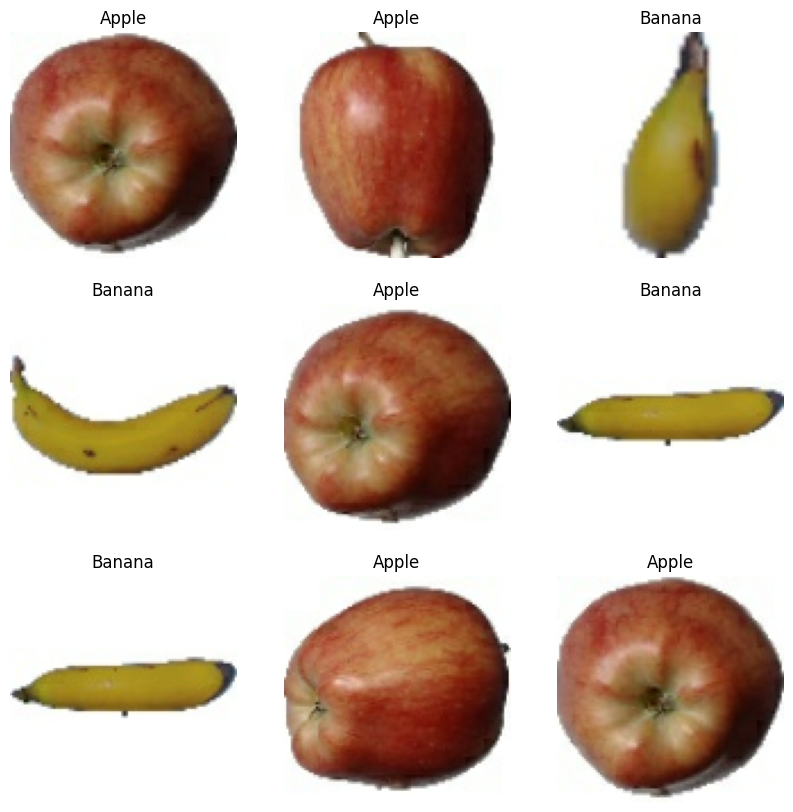

In [35]:
import matplotlib.pyplot as plt

class_names = test_dataset.class_names

for images, labels in test_dataset.take(1):
    plt.figure(figsize=(10,10))
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [36]:
for _, labels in test_dataset.take(1):
    print(labels.numpy())

[2 1 1 1 1 1 1 1 1 1 1 2 1 0 2 0 2 1 0 2 0 0 0 2 2 1 1 2 1 0 2 1]


In [38]:
history = new_model.fit(
    train_dataset,
    epochs = 50,
    validation_data=(test_dataset),
    callbacks = [early_stop, checkpoint, reduce_lr]
)

Epoch 1/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - accuracy: 0.9836 - loss: 0.0727 - val_accuracy: 0.5796 - val_loss: 1.1158 - learning_rate: 5.0000e-04
Epoch 2/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 1.0000 - loss: 8.3211e-04 - val_accuracy: 0.6735 - val_loss: 1.8081 - learning_rate: 5.0000e-04
Epoch 3/50
45/46 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 1.0000 - loss: 4.9558e-04
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 1.0000 - loss: 7.0567e-04 - val_accuracy: 0.4939 - val_loss: 2.9496 - learning_rate: 5.0000e-04
Epoch 4/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 1.0000 - loss: 2.4094e-04 - val_accuracy: 0.3347 - val_loss: 3.6699 - learning_rate: 2.5000e-04
Epoch 5/50
45/46 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 1.0000 - loss: 1.5346e-04
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accurac

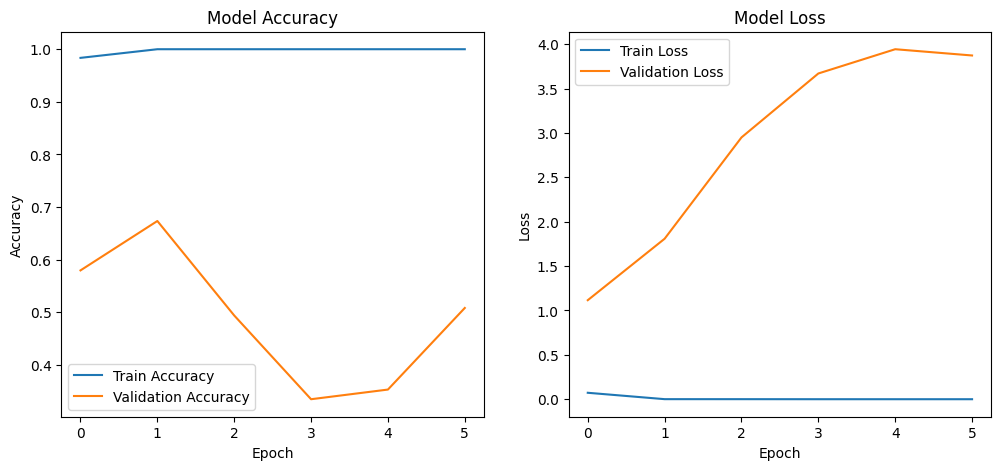

In [39]:
from matplotlib import pyplot as plt
plt.figure(figsize=(12,5))


plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()


plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [41]:
train_loss, train_acc = new_model.evaluate(train_dataset)
test_loss, test_acc = new_model.evaluate(test_dataset)

print(train_acc)
print(test_acc)

46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6010 - loss: 1.0886
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5796 - loss: 1.1158
0.6009582281112671
0.5795918107032776
